## IPL win predictor
### Tools: Pandas, NumPy, Matplotlib, Sklearn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

### Load the data

In [2]:
df = pd.read_csv('matches.csv')  # Download from kaggle


### basic code

In [3]:
print("Shape:", df.shape)


Shape: (1095, 20)


In [4]:
print("\nFirst 5 rows:")
print(df.head())



First 5 rows:
       id   season        city        date match_type player_of_match  \
0  335982  2007/08   Bangalore  2008-04-18     League     BB McCullum   
1  335983  2007/08  Chandigarh  2008-04-19     League      MEK Hussey   
2  335984  2007/08       Delhi  2008-04-19     League     MF Maharoof   
3  335985  2007/08      Mumbai  2008-04-20     League      MV Boucher   
4  335986  2007/08     Kolkata  2008-04-20     League       DJ Hussey   

                                        venue                        team1  \
0                       M Chinnaswamy Stadium  Royal Challengers Bangalore   
1  Punjab Cricket Association Stadium, Mohali              Kings XI Punjab   
2                            Feroz Shah Kotla             Delhi Daredevils   
3                            Wankhede Stadium               Mumbai Indians   
4                                Eden Gardens        Kolkata Knight Riders   

                         team2                  toss_winner toss_decision  \


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [6]:
print("\nColumns:")
print(df.columns.tolist())



Columns:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [7]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [8]:
print("\nTotal matches:", len(df))
print("Seasons:", df['season'].unique())


Total matches: 1095
Seasons: ['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018' '2019' '2020/21' '2021' '2022' '2023' '2024']


In [9]:
print("Top 10 winning teams:\n")
print(df['winner'].value_counts().head(10))

Top 10 winning teams:

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64


### Visualization from matplotlib

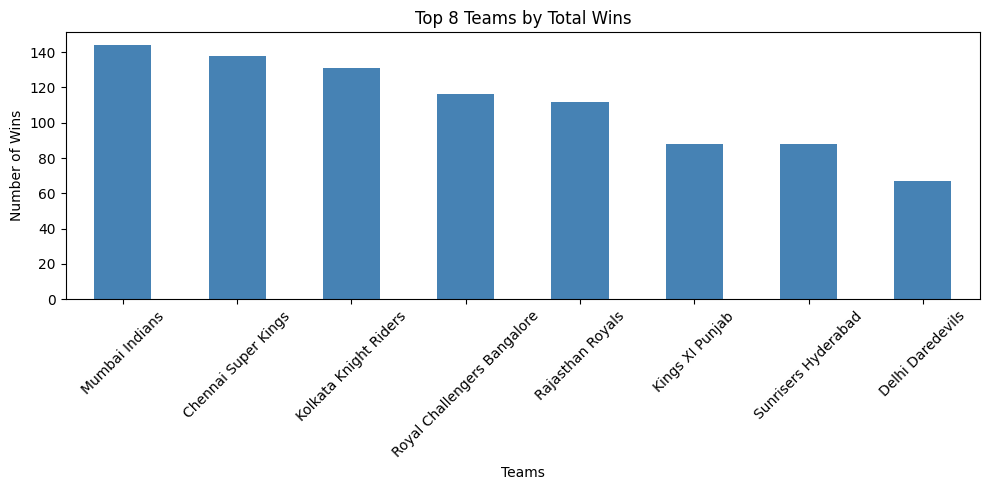

In [10]:
plt.figure(figsize=(10, 5))
df['winner'].value_counts().head(8).plot(kind='bar', color='steelblue')
plt.title('Top 8 Teams by Total Wins')
plt.xlabel('Teams')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

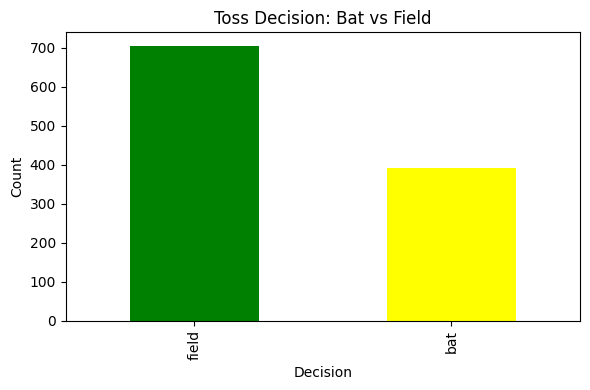

In [11]:
plt.figure(figsize=(6, 4))
df['toss_decision'].value_counts().plot(kind='bar', color=['green', 'yellow'])
plt.title('Toss Decision: Bat vs Field')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

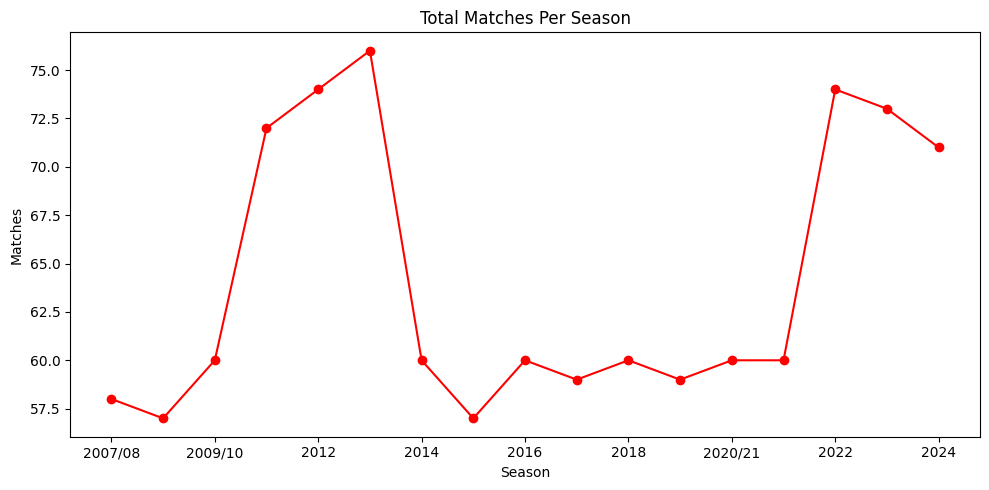

In [12]:
plt.figure(figsize=(10, 5))
df.groupby('season')['winner'].count().plot(kind='line', marker='o', color='red')
plt.title('Total Matches Per Season')
plt.xlabel('Season')
plt.ylabel('Matches')
plt.tight_layout()
plt.show()


### Feature engineering 

In [13]:
df_model = df[['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'winner']].copy()


In [14]:
df_model.head()

,team1,team2,toss_winner,toss_decision,venue,winner
0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Kolkata Knight Riders
1,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings
2,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi Daredevils
3,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Wankhede Stadium,Royal Challengers Bangalore
4,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Eden Gardens,Kolkata Knight Riders


In [15]:
df_model.shape
print("Before  cleaning, shape:", df_model.shape)


Before  cleaning, shape: (1095, 6)


In [16]:
df_model.dropna(inplace=True)
print("\nAfter cleaning, shape:", df_model.shape)



After cleaning, shape: (1090, 6)


In [17]:
df_model['toss_win_match_win'] = (df_model['toss_winner'] == df_model['winner']).astype(int)
print("\nToss winner = Match winner?")
print(df_model['toss_win_match_win'].value_counts())



Toss winner = Match winner?
toss_win_match_win
1    554
0    536
Name: count, dtype: int64


In [18]:
df_model['target'] = (df_model['winner'] == df_model['team1']).astype(int)


### Label encoding(text --> numbers)

In [19]:
le = LabelEncoder()

df_model['team1_enc']        = le.fit_transform(df_model['team1'])
df_model['team2_enc']        = le.fit_transform(df_model['team2'])
df_model['toss_winner_enc']  = le.fit_transform(df_model['toss_winner'])
df_model['toss_decision_enc']= le.fit_transform(df_model['toss_decision'])
df_model['venue_enc']        = le.fit_transform(df_model['venue'])


### Train test split

In [20]:
X = df_model[['team1_enc', 'team2_enc', 'toss_winner_enc',
              'toss_decision_enc', 'venue_enc', 'toss_win_match_win']]

y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")


Training samples: 872
Testing samples:  218


 #### Model1: logistic regression

In [22]:
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)

print("\n--- Logistic Regression ---")
print(f"Accuracy: {lr_acc * 100:.2f}%")
print(classification_report(y_test, lr_pred))


--- Logistic Regression ---
Accuracy: 62.39%
              precision    recall  f1-score   support

           0       0.62      0.65      0.64       110
           1       0.63      0.59      0.61       108

    accuracy                           0.62       218
   macro avg       0.62      0.62      0.62       218
weighted avg       0.62      0.62      0.62       218



#### Model2 :KNN classifier


In [27]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_acc  = accuracy_score(y_test, knn_pred)

print("\n--- KNN Classifier ---")
print(f"Accuracy: {knn_acc * 100:.2f}%")
print(classification_report(y_test, knn_pred))


--- KNN Classifier ---
Accuracy: 54.13%
              precision    recall  f1-score   support

           0       0.55      0.52      0.53       110
           1       0.54      0.56      0.55       108

    accuracy                           0.54       218
   macro avg       0.54      0.54      0.54       218
weighted avg       0.54      0.54      0.54       218



### Model comparison

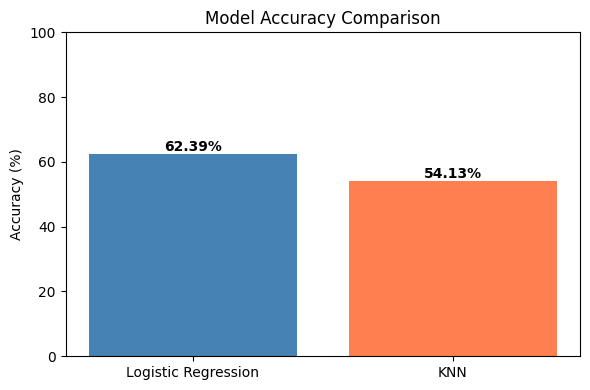

In [28]:
models     = ['Logistic Regression', 'KNN']
accuracies = [lr_acc * 100, knn_acc * 100]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies, color=['steelblue', 'coral'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
print("FINAL SUMMARY")
print(f"Logistic Regression Accuracy : {lr_acc * 100:.2f}%")
print(f"KNN Accuracy                 : {knn_acc * 100:.2f}%")

if lr_acc >= knn_acc:
    print("Best Model: Logistic Regression")
else:
    print("Best Model: KNN")

FINAL SUMMARY
Logistic Regression Accuracy : 62.39%
KNN Accuracy                 : 54.13%
Best Model: Logistic Regression
